In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")

In [3]:
df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

In [4]:
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical_cols.tolist())


Categorical columns: []


Random Forest Accuracy: 0.8773
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.86        74
           1       0.87      0.93      0.90        72
           2       0.89      0.85      0.87        74

    accuracy                           0.88       220
   macro avg       0.88      0.88      0.88       220
weighted avg       0.88      0.88      0.88       220

------------------------------------------------------------
Gradient Boosting Accuracy: 0.8682
Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.84      0.86        74
           1       0.84      0.94      0.89        72
           2       0.88      0.82      0.85        74

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220

-------------------------------

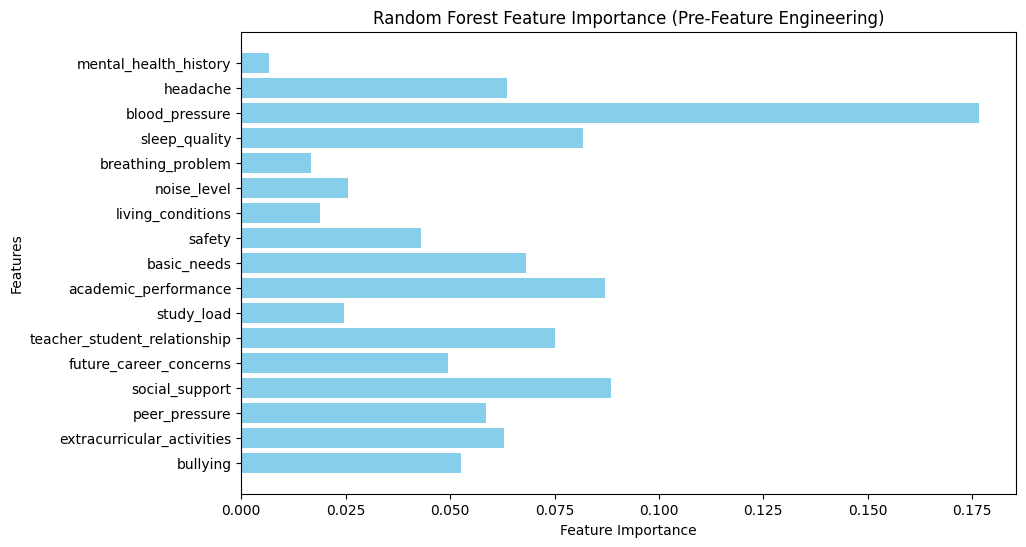

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")

# ----------------------------
# Remove target & leakage features
# ----------------------------
target = "stress_level"
leakage_features = ["anxiety_level", "self_esteem", "depression"]

X = df.drop(columns=[target] + leakage_features)
y = df[target]

# ----------------------------
# Train-test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ----------------------------
# Define models
# ----------------------------
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# ----------------------------
# Train & evaluate individual models
# ----------------------------
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")
    print(f"{name} Classification Report:\n", classification_report(y_test, y_pred))
    print("-"*60)

# ----------------------------
# Ensemble: Voting Classifier
# ----------------------------
ensemble = VotingClassifier(
    estimators=[(name, model) for name, model in models.items()],
    voting='soft'  # soft voting for probabilities
)
ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)
acc_ens = accuracy_score(y_test, y_pred_ens)
print(f"Ensemble Accuracy: {acc_ens:.4f}")
print("Ensemble Classification Report:\n", classification_report(y_test, y_pred_ens))

# ----------------------------
# Feature Importance for Random Forest
# ----------------------------
importances = models["Random Forest"].feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances, color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance (Pre-Feature Engineering)")
plt.show()


Correlation with Stress Level:

stress_level                    1.000000
bullying                        0.760263
future_career_concerns          0.753981
depression                      0.746773
anxiety_level                   0.741869
headache                        0.736590
extracurricular_activities      0.702437
noise_level                     0.695952
peer_pressure                   0.693609
study_load                      0.665697
mental_health_history           0.648632
breathing_problem               0.589575
blood_pressure                  0.444069
living_conditions              -0.637287
social_support                 -0.643672
teacher_student_relationship   -0.686947
safety                         -0.714113
basic_needs                    -0.719037
academic_performance           -0.728272
sleep_quality                  -0.760959
self_esteem                    -0.779133
Name: stress_level, dtype: float64


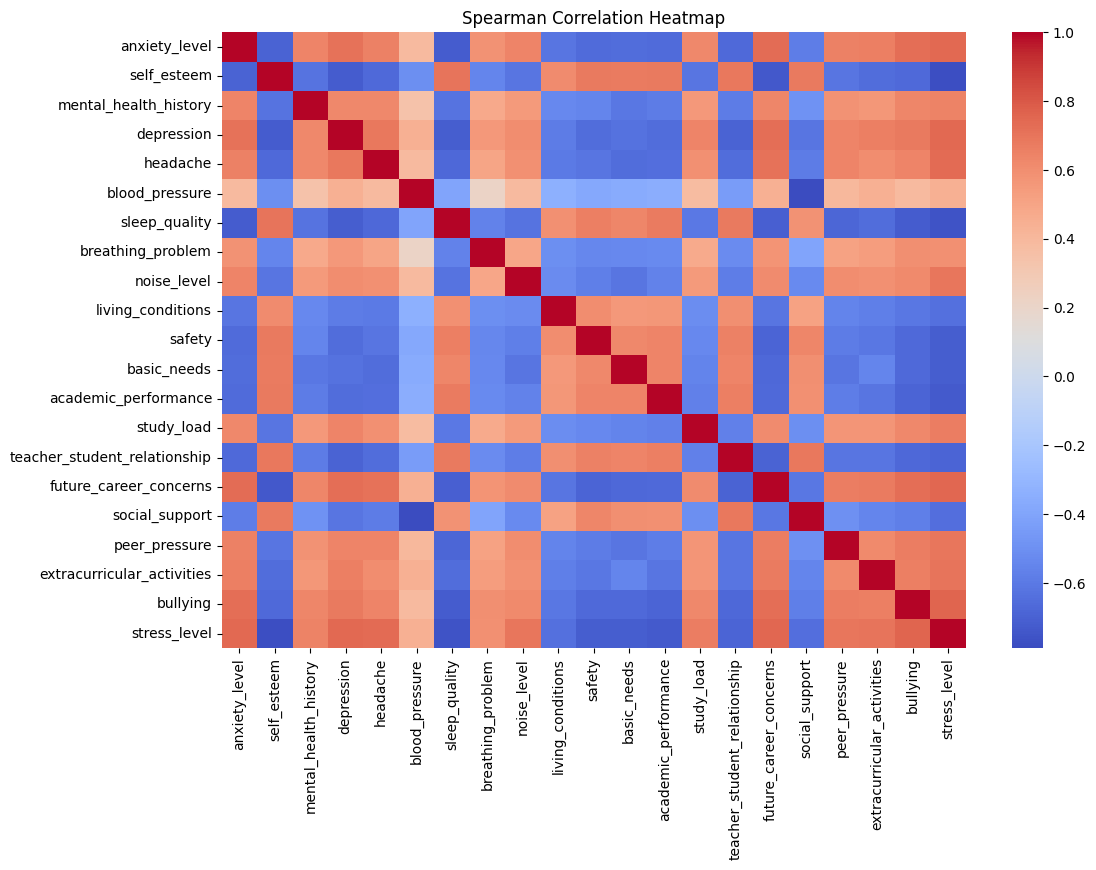

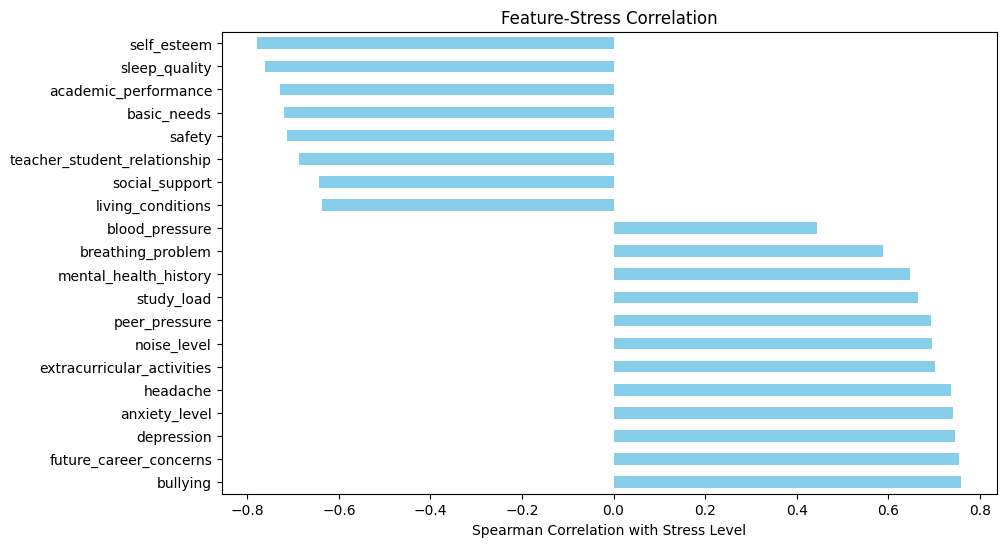

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")

# Compute Spearman correlation
corr = df.corr(method="spearman")

# Correlation with stress_level only
stress_corr = corr["stress_level"].sort_values(ascending=False)

print("Correlation with Stress Level:\n")
print(stress_corr)

# Heatmap of full correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=False, cbar=True)
plt.title("Spearman Correlation Heatmap")
plt.show()

# Barplot for correlation with stress_level
plt.figure(figsize=(10,6))
stress_corr.drop("stress_level").plot(kind="barh", color="skyblue")
plt.xlabel("Spearman Correlation with Stress Level")
plt.title("Feature-Stress Correlation")
plt.show()


In [8]:
import pandas as pd
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")

# Target
y = df["stress_level"]

# Drop leakage & target
X = df.drop(columns=["stress_level", "anxiety_level", "self_esteem", "depression"])

# Scale features (chi2 requires non-negative values)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Apply Chi-Square test
chi_scores, p_values = chi2(X_scaled, y)

# Put into dataframe
chi2_results = pd.DataFrame({
    "Feature": X.columns,
    "Chi2 Score": chi_scores,
    "p-value": p_values
}).sort_values(by="Chi2 Score", ascending=False)

print("Chi-Square Test Results:\n")
print(chi2_results)


Chi-Square Test Results:

                         Feature  Chi2 Score       p-value
0          mental_health_history  234.803053  1.030777e-51
2                 blood_pressure  215.984923  1.257389e-47
3                  sleep_quality  111.774047  5.352715e-25
16                      bullying  111.243192  6.979878e-25
12        future_career_concerns  107.722084  4.059258e-24
13                social_support   93.960090  3.952080e-21
1                       headache   88.722438  5.422098e-20
9           academic_performance   85.373125  2.893753e-19
8                    basic_needs   85.140418  3.250822e-19
7                         safety   83.837721  6.235485e-19
14                 peer_pressure   80.952641  2.638501e-18
15    extracurricular_activities   79.899465  4.467366e-18
11  teacher_student_relationship   76.900112  2.001487e-17
5                    noise_level   65.211423  6.910657e-15
10                    study_load   58.711826  1.781923e-13
4              breathing_probl


Combined Results (Chi-Square + Correlation):

                              Chi2 Score       p-value  Spearman Corr
Feature                                                              
mental_health_history         234.803053  1.030777e-51       0.648632
blood_pressure                215.984923  1.257389e-47       0.444069
sleep_quality                 111.774047  5.352715e-25      -0.760959
bullying                      111.243192  6.979878e-25       0.760263
future_career_concerns        107.722084  4.059258e-24       0.753981
social_support                 93.960090  3.952080e-21      -0.643672
headache                       88.722438  5.422098e-20       0.736590
academic_performance           85.373125  2.893753e-19      -0.728272
basic_needs                    85.140418  3.250822e-19      -0.719037
safety                         83.837721  6.235485e-19      -0.714113
peer_pressure                  80.952641  2.638501e-18       0.693609
extracurricular_activities     79.899465  4

/tmp/ipython-input-2996662183.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results.reset_index(), x="Chi2 Score", y="Feature", palette="viridis")


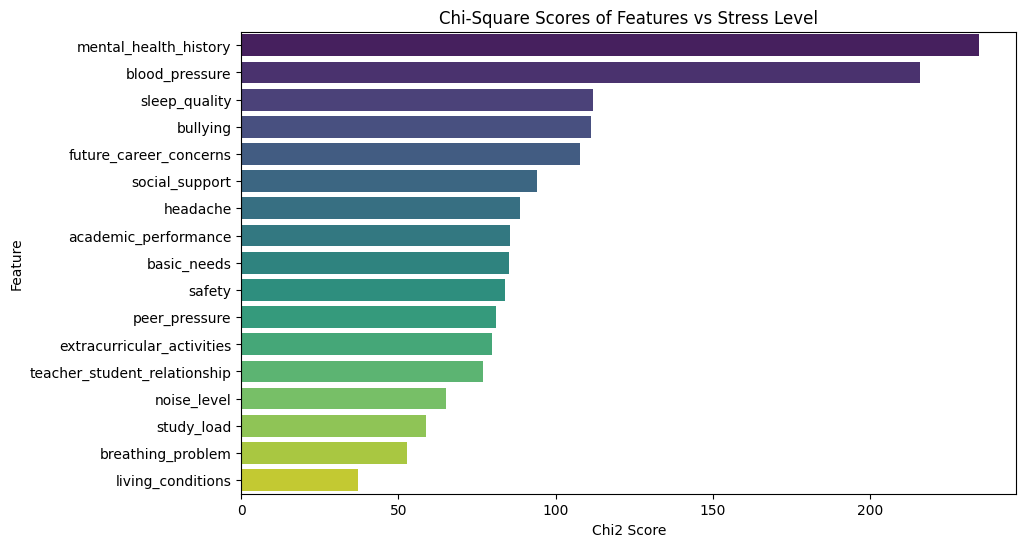

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Spearman correlation with stress level
corr = df.corr(method="spearman")["stress_level"].drop("stress_level")

# Merge Chi-Square & Correlation
results = chi2_results.set_index("Feature").join(corr).rename(columns={"stress_level": "Spearman Corr"})

print("\nCombined Results (Chi-Square + Correlation):\n")
print(results.sort_values(by="Chi2 Score", ascending=False))

# Visualization
plt.figure(figsize=(10,6))
sns.barplot(data=results.reset_index(), x="Chi2 Score", y="Feature", palette="viridis")
plt.title("Chi-Square Scores of Features vs Stress Level")
plt.show()


Significant features: ['mental_health_history', 'blood_pressure', 'sleep_quality', 'bullying', 'future_career_concerns', 'social_support', 'headache', 'academic_performance', 'basic_needs', 'safety', 'peer_pressure', 'extracurricular_activities', 'teacher_student_relationship', 'noise_level', 'study_load', 'breathing_problem', 'living_conditions']


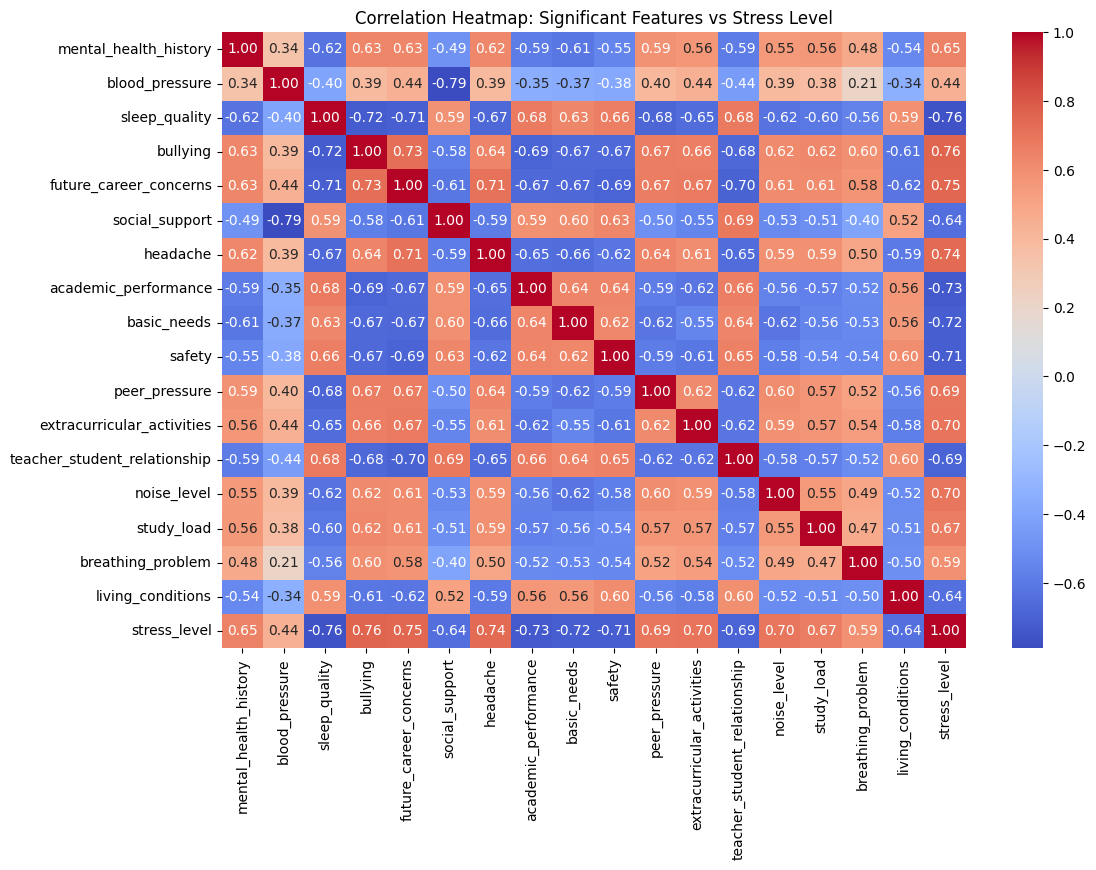

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use your Chi-Square + correlation results
results = pd.DataFrame({
    "Feature": [
        "mental_health_history","blood_pressure","sleep_quality","bullying",
        "future_career_concerns","social_support","headache","academic_performance",
        "basic_needs","safety","peer_pressure","extracurricular_activities",
        "teacher_student_relationship","noise_level","study_load","breathing_problem",
        "living_conditions"
    ],
    "Chi2 Score": [
        234.803053,215.984923,111.774047,111.243192,107.722084,93.960090,88.722438,
        85.373125,85.140418,83.837721,80.952641,79.899465,76.900112,65.211423,
        58.711826,52.712701,37.005998
    ],
    "p-value": [
        1.030777e-51,1.257389e-47,5.352715e-25,6.979878e-25,4.059258e-24,3.952080e-21,
        5.422098e-20,2.893753e-19,3.250822e-19,6.235485e-19,2.638501e-18,4.467366e-18,
        2.001487e-17,6.910657e-15,1.781923e-13,3.577523e-12,9.209787e-09
    ],
    "Spearman Corr": [
        0.648632,0.444069,-0.760959,0.760263,0.753981,-0.643672,0.736590,
        -0.728272,-0.719037,-0.714113,0.693609,0.702437,-0.686947,0.695952,
        0.665697,0.589575,-0.637287
    ]
})

# Select only significant features (p < 0.05)
significant_features = results[results["p-value"] < 0.05]["Feature"].tolist()

print("Significant features:", significant_features)

# Subset dataframe with significant features + target
df_sig = df[significant_features + ["stress_level"]]

# Correlation matrix (Spearman for ordinal data)
corr_sig = df_sig.corr(method="spearman")

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_sig, cmap="coolwarm", annot=True, fmt=".2f", cbar=True)
plt.title("Correlation Heatmap: Significant Features vs Stress Level")
plt.show()


In [11]:
import numpy as np

# Apply thresholds
chi2_threshold = 80
corr_threshold = 0.6

selected_features = results[
    (results["Chi2 Score"] > chi2_threshold) | (results["Spearman Corr"].abs() > corr_threshold)
]["Feature"].tolist()

print("Selected Important Features (after thresholding):\n", selected_features)

# Final dataset for modeling
X_selected = df[selected_features]
y = df["stress_level"]

print("\nShape before feature selection:", df.shape)
print("Shape after feature selection:", X_selected.shape)


Selected Important Features (after thresholding):
 ['mental_health_history', 'blood_pressure', 'sleep_quality', 'bullying', 'future_career_concerns', 'social_support', 'headache', 'academic_performance', 'basic_needs', 'safety', 'peer_pressure', 'extracurricular_activities', 'teacher_student_relationship', 'noise_level', 'study_load', 'living_conditions']

Shape before feature selection: (1100, 21)
Shape after feature selection: (1100, 16)



Random Forest Feature Importances:
                          Feature  Importance
1                 blood_pressure    0.169453
2                  sleep_quality    0.095135
12  teacher_student_relationship    0.092716
7           academic_performance    0.087805
5                 social_support    0.079046
8                    basic_needs    0.071480
3                       bullying    0.064084
10                 peer_pressure    0.059197
6                       headache    0.054084
9                         safety    0.050706
4         future_career_concerns    0.049840
11    extracurricular_activities    0.048058
14                    study_load    0.024581
13                   noise_level    0.023662
15             living_conditions    0.022341
0          mental_health_history    0.007813


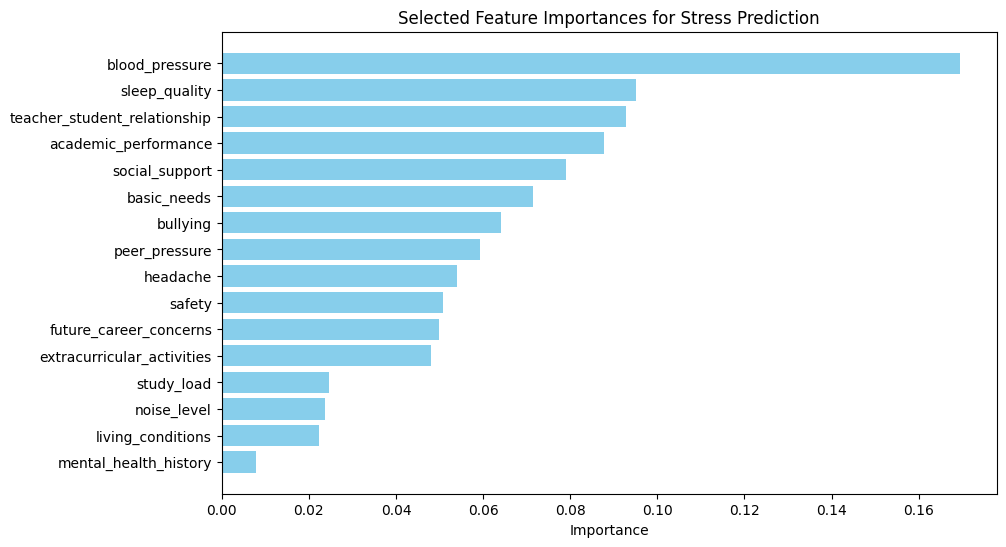

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Train model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Feature importance
importances = rf.feature_importances_
feat_importance = pd.DataFrame({"Feature": selected_features, "Importance": importances})
feat_importance = feat_importance.sort_values(by="Importance", ascending=False)

print("\nRandom Forest Feature Importances:\n", feat_importance)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_importance["Feature"], feat_importance["Importance"], color="skyblue")
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Selected Feature Importances for Stress Prediction")
plt.show()


In [32]:
import numpy as np

# Higher thresholds for stronger features
chi2_threshold = 150       # only features with Chi2 > 100
corr_threshold = 0.70      # only features with |Spearman Corr| > 0.7

selected_features = results[
    (results["Chi2 Score"] > chi2_threshold) | (results["Spearman Corr"].abs() > corr_threshold)
]["Feature"].tolist()

print("Selected Important Features (after higher thresholding):\n", selected_features)

# Final dataset for modeling
X_selected = df[selected_features]
y = df["stress_level"]

print("\nShape before feature selection:", df.shape)
print("Shape after feature selection:", X_selected.shape)


Selected Important Features (after higher thresholding):
 ['mental_health_history', 'blood_pressure', 'sleep_quality', 'bullying', 'future_career_concerns', 'headache', 'academic_performance', 'basic_needs', 'safety', 'extracurricular_activities']

Shape before feature selection: (1100, 21)
Shape after feature selection: (1100, 10)


In [37]:
import numpy as np

# Higher thresholds for stronger features
chi2_threshold = 150       # only features with Chi2 > 100
corr_threshold = 0.72      # only features with |Spearman Corr| > 0.7

selected_features = results[
    (results["Chi2 Score"] > chi2_threshold) | (results["Spearman Corr"].abs() > corr_threshold)
]["Feature"].tolist()

print("Selected Important Features (after higher thresholding):\n", selected_features)

# Final dataset for modeling
X_selected = df[selected_features]
y = df["stress_level"]

print("\nShape before feature selection:", df.shape)
print("Shape after feature selection:", X_selected.shape)


Selected Important Features (after higher thresholding):
 ['mental_health_history', 'blood_pressure', 'sleep_quality', 'bullying', 'future_career_concerns', 'headache', 'academic_performance']

Shape before feature selection: (1100, 21)
Shape after feature selection: (1100, 7)


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")

# Selected features from previous step
selected_features = [
    'mental_health_history', 'blood_pressure', 'sleep_quality', 'bullying',
    'future_career_concerns', 'social_support', 'headache',
    'academic_performance', 'basic_needs', 'safety', 'peer_pressure',
    'extracurricular_activities', 'teacher_student_relationship',
    'noise_level', 'study_load', 'living_conditions'
]

X = df[selected_features]
y = df['stress_level']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")

# Detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Random Forest Accuracy: 0.8727

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.84      0.86        74
           1       0.88      0.92      0.90        72
           2       0.85      0.86      0.86        74

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220



In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")

# Selected top 10 features
selected_features = [
    'mental_health_history', 'blood_pressure', 'sleep_quality', 'bullying',
    'future_career_concerns', 'headache', 'academic_performance',
    'basic_needs', 'safety', 'extracurricular_activities'
]

X = df[selected_features]
y = df['stress_level']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")

# Detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Random Forest Accuracy: 0.8591

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.82      0.85        74
           1       0.88      0.90      0.89        72
           2       0.83      0.85      0.84        74

    accuracy                           0.86       220
   macro avg       0.86      0.86      0.86       220
weighted avg       0.86      0.86      0.86       220



Random Forest Accuracy (14 features): 0.8636

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84        74
           1       0.90      0.90      0.90        72
           2       0.85      0.85      0.85        74

    accuracy                           0.86       220
   macro avg       0.86      0.86      0.86       220
weighted avg       0.86      0.86      0.86       220



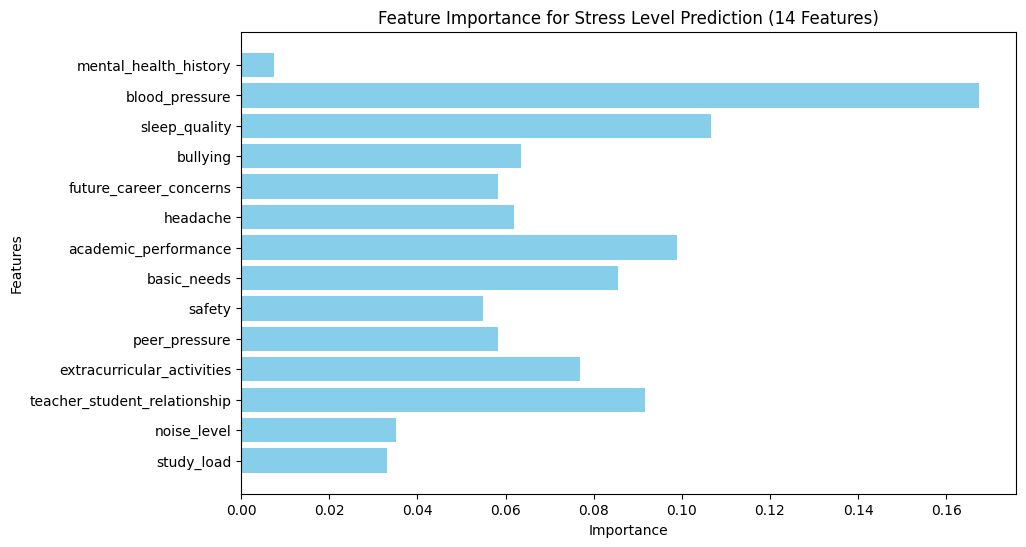

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")

# ----------------------------
# Selected features (no leakage)
# ----------------------------
selected_features = [
    'mental_health_history', 'blood_pressure', 'sleep_quality', 'bullying',
    'future_career_concerns', 'headache', 'academic_performance', 'basic_needs',
    'safety', 'peer_pressure', 'extracurricular_activities',
    'teacher_student_relationship', 'noise_level', 'study_load'
]

X = df[selected_features]
y = df["stress_level"]

# ----------------------------
# Train-test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ----------------------------
# Train Random Forest
# ----------------------------
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# ----------------------------
# Predictions & Evaluation
# ----------------------------
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy (14 features): {accuracy:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ----------------------------
# Feature Importance
# ----------------------------
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances, color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance for Stress Level Prediction (14 Features)")
plt.show()


Random Forest Accuracy: 0.8848
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87       112
           1       0.91      0.90      0.91       107
           2       0.87      0.89      0.88       111

    accuracy                           0.88       330
   macro avg       0.89      0.89      0.89       330
weighted avg       0.89      0.88      0.88       330

------------------------------------------------------------
Gradient Boosting Accuracy: 0.8636
Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.84      0.86       112
           1       0.85      0.88      0.87       107
           2       0.86      0.87      0.87       111

    accuracy                           0.86       330
   macro avg       0.86      0.86      0.86       330
weighted avg       0.86      0.86      0.86       330

-------------------------------

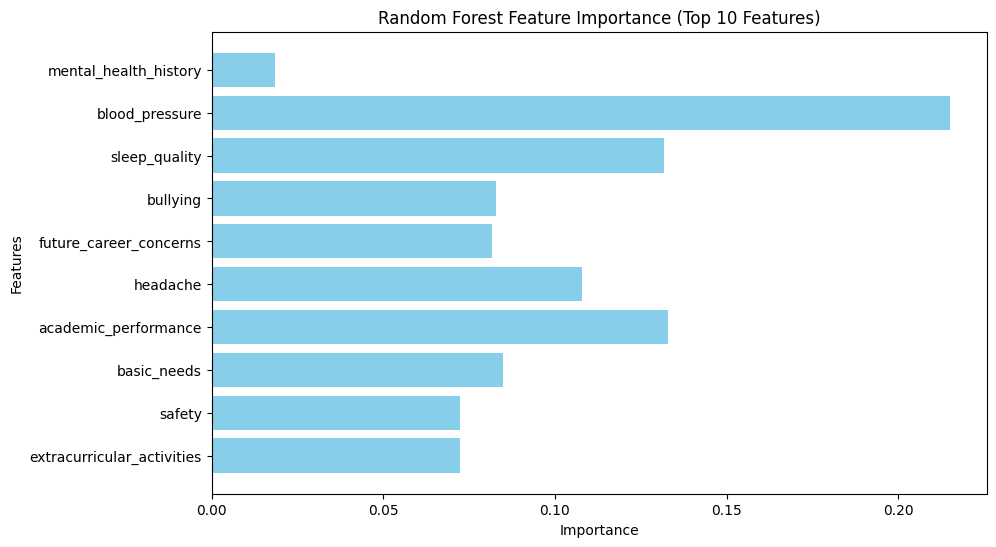

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Conforence/Stress/StressLevelDataset.csv")

# ----------------------------
# Top 10 selected features (no leakage)
# ----------------------------
selected_features = [
    'mental_health_history', 'blood_pressure', 'sleep_quality', 'bullying',
    'future_career_concerns', 'headache', 'academic_performance', 'basic_needs',
    'safety', 'extracurricular_activities'
]

X = df[selected_features]
y = df["stress_level"]

# ----------------------------
# Train-test split (30% test)
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ----------------------------
# Define models
# ----------------------------
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# ----------------------------
# Train & evaluate individual models
# ----------------------------
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")
    print(f"{name} Classification Report:\n", classification_report(y_test, y_pred))
    print("-"*60)

# ----------------------------
# Ensemble: Voting Classifier
# ----------------------------
ensemble = VotingClassifier(
    estimators=[(name, model) for name, model in models.items()],
    voting='soft'  # soft voting for probabilities
)
ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)
acc_ens = accuracy_score(y_test, y_pred_ens)
print(f"Ensemble Accuracy: {acc_ens:.4f}")
print("Ensemble Classification Report:\n", classification_report(y_test, y_pred_ens))

# ----------------------------
# Feature Importance for Random Forest
# ----------------------------
importances = models["Random Forest"].feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances, color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance (Top 10 Features)")
plt.show()
